# DS-3002 Assignment 4: Heart Disease + MNIST

Complete notebook scaffold for preprocessing, clustering, ensemble methods, neural networks, CNNs, and a local dashboard artifact export.

In [1]:
# Core imports will be added in the next cells.

In [11]:
pip install numpy pandas matplotlib seaborn scipy scikit-learn joblib xgboost shap tensorflow streamlit

In [3]:
import json
import os
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    silhouette_score,
    adjusted_rand_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
np.random.seed(SEED)

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
ARTIFACT_DIR = BASE_DIR / "artifacts"
APP_DIR = BASE_DIR / "app"
for folder in (DATA_DIR, ARTIFACT_DIR, APP_DIR):
    folder.mkdir(parents=True, exist_ok=True)

HEART_COLUMNS = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target",
]

NUMERIC_ORIGINAL_COLUMNS = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
]

CONTINUOUS_COLUMNS = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]
CATEGORICAL_COLUMNS = ["cp", "restecg", "slope", "thal"]
PASS_THROUGH_COLUMNS = ["sex", "fbs", "exang"]
TARGET_COLUMN = "target"


def evaluate_binary_model(y_true, y_pred, y_proba, label="model"):
    results = {
        "model": label,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "auc_roc": roc_auc_score(y_true, y_proba),
        "recall_disease": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_no_disease": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
    }
    return results


def print_metrics(results):
    print(f"\n[{results['model']}]")
    print(f"Accuracy: {results['accuracy']:.4f}")
    print(f"Macro precision: {results['macro_precision']:.4f}")
    print(f"Macro recall: {results['macro_recall']:.4f}")
    print(f"Macro F1: {results['macro_f1']:.4f}")
    print(f"AUC-ROC: {results['auc_roc']:.4f}")
    print("Confusion matrix:\n", results["confusion_matrix"])


def show_confusion_matrix(cm, title):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [4]:
# Heart Disease dataset download and cleaning
uci_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
heart_path = DATA_DIR / "processed.cleveland.data"
if not heart_path.exists():
    import urllib.request
    urllib.request.urlretrieve(uci_url, heart_path)

heart_raw = pd.read_csv(heart_path, header=None, names=HEART_COLUMNS)
print("Raw shape:", heart_raw.shape)
print("First 5 rows:\n", heart_raw.head())
print("Data types before cleaning:\n", heart_raw.dtypes)

heart_raw = heart_raw.replace("?", np.nan)
for col in HEART_COLUMNS:
    heart_raw[col] = pd.to_numeric(heart_raw[col], errors="coerce")

print("Missing values after replacing '?':\n", heart_raw.isna().sum().sort_values(ascending=False))
heart_clean = heart_raw.dropna().copy()
heart_clean[TARGET_COLUMN] = (heart_clean[TARGET_COLUMN] > 0).astype(int)
print("Retained rows after dropping missing values:", len(heart_clean))
print("Target distribution:\n", heart_clean[TARGET_COLUMN].value_counts().sort_index())
print((heart_clean[TARGET_COLUMN].value_counts(normalize=True) * 100).round(2))

X_full_raw = heart_clean.drop(columns=[TARGET_COLUMN]).copy()
y_full = heart_clean[TARGET_COLUMN].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_full_raw,
    y_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_full,
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), CONTINUOUS_COLUMNS),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_COLUMNS),
    ],
    remainder="passthrough",
)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)
X_all = preprocessor.transform(X_full_raw)
feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(X_train, columns=feature_names, index=X_train_raw.index)
X_test_df = pd.DataFrame(X_test, columns=feature_names, index=X_test_raw.index)
X_all_df = pd.DataFrame(X_all, columns=feature_names, index=X_full_raw.index)

print("Train shape:", X_train_df.shape)
print("Test shape:", X_test_df.shape)
print("Processed feature names:\n", list(feature_names))


Raw shape: (303, 14)
First 5 rows:
     age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca thal  target  
0    3.0  0.0  6.0       0  
1    2.0  3.0  3.0       2  
2    2.0  2.0  7.0       1  
3    3.0  0.0  3.0       0  
4    1.0  0.0  3.0       0  
Data types before cleaning:
 age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca           object
thal         object
target        int64
dtype: object
Miss

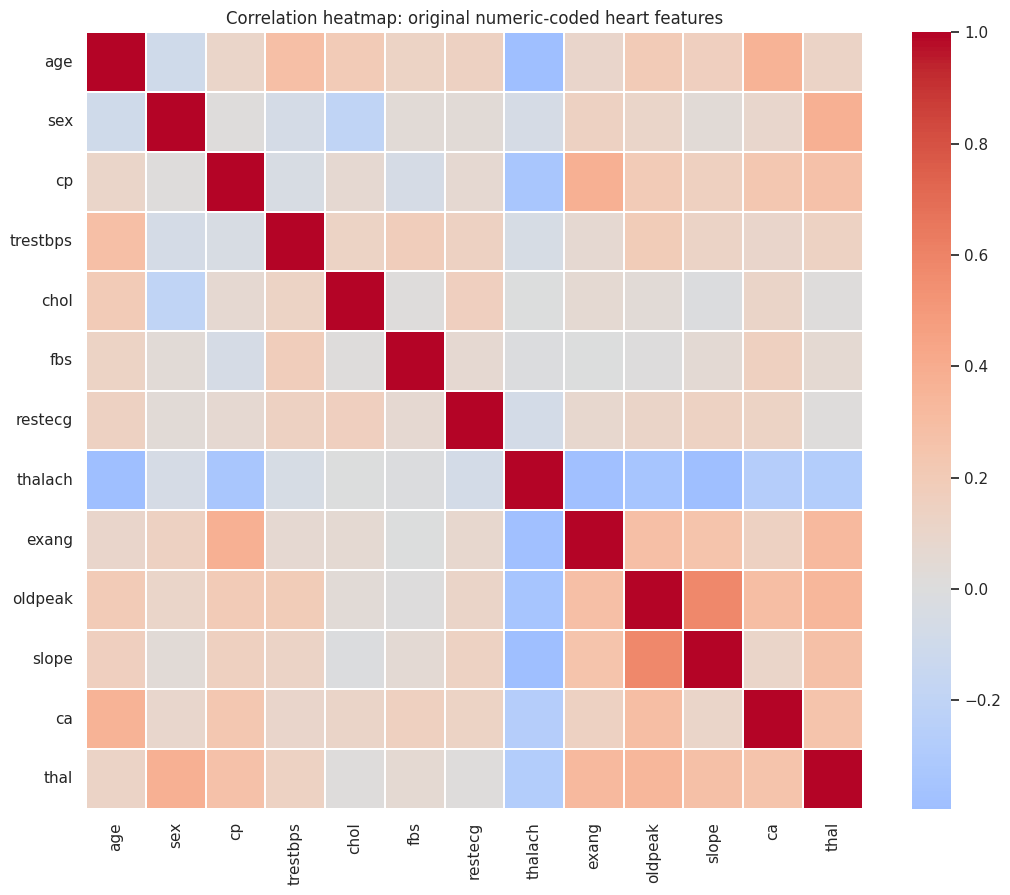

Top 3 correlated feature pairs:
 oldpeak  slope      0.579037
age      thalach    0.394563
slope    thalach    0.389307
dtype: float64
Note: strong correlations can inflate variance in linear probabilistic models, but tree models are usually less sensitive.


In [5]:
# Correlation heatmap on original numeric-coded features
corr_matrix = heart_clean[NUMERIC_ORIGINAL_COLUMNS].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True, linewidths=0.2)
plt.title("Correlation heatmap: original numeric-coded heart features")
plt.tight_layout()
plt.show()

corr_abs = corr_matrix.abs().where(~np.eye(len(corr_matrix), dtype=bool))
top_pairs = (
    corr_abs.unstack()
    .dropna()
    .sort_values(ascending=False)
    .drop_duplicates()
    .head(3)
)
print("Top 3 correlated feature pairs:\n", top_pairs)
print("Note: strong correlations can inflate variance in linear probabilistic models, but tree models are usually less sensitive.")


K values: [2, 3, 4, 5, 6, 7, 8]
Inertia: [2133.08, 1948.23, 1810.68, 1721.35, 1654.2, 1590.95, 1543.71]
Silhouette: [np.float64(0.1762), np.float64(0.1237), np.float64(0.1322), np.float64(0.1295), np.float64(0.1223), np.float64(0.1048), np.float64(0.0943)]
Chosen k: 2


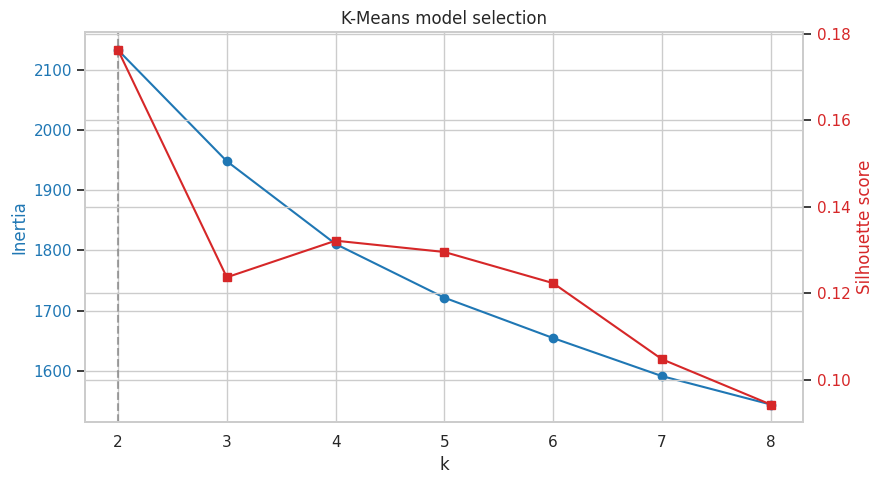

ARI vs true labels: 0.2988


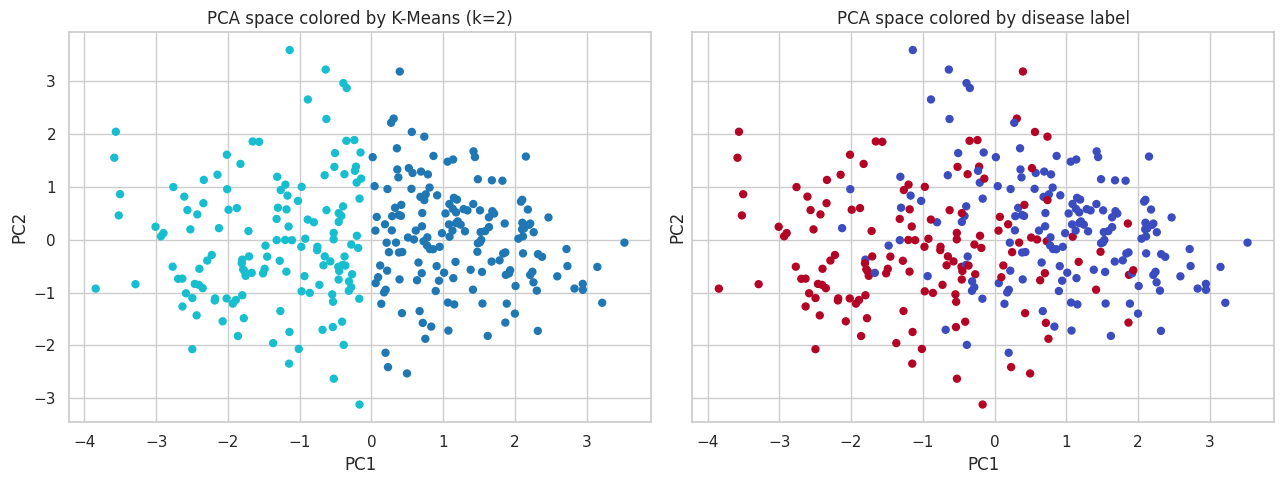

         size  disease_rate  mean_thalach  mean_oldpeak   mean_cp
cluster                                                          
0         157         20.38    163.369427      0.494268  2.885350
1         140         75.00    134.157143      1.685000  3.464286
Interpretation placeholder: write 1–2 sentences per cluster using the disease rate and feature means.


In [6]:
# Part A1: K-Means clustering
k_values = list(range(2, 9))
inertias = []
silhouettes = []
kmeans_models = {}

for k in k_values:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    labels = km.fit_predict(X_all_df)
    kmeans_models[k] = km
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_all_df, labels))

chosen_k = k_values[int(np.argmax(silhouettes))]
print("K values:", k_values)
print("Inertia:", [round(v, 2) for v in inertias])
print("Silhouette:", [round(v, 4) for v in silhouettes])
print("Chosen k:", chosen_k)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(k_values, inertias, marker="o", color="tab:blue", label="WCSS / inertia")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2 = ax1.twinx()
ax2.plot(k_values, silhouettes, marker="s", color="tab:red", label="Silhouette")
ax2.set_ylabel("Silhouette score", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax1.axvline(chosen_k, linestyle="--", color="gray", alpha=0.7)
plt.title("K-Means model selection")
fig.tight_layout()
plt.show()

kmeans_final = KMeans(n_clusters=chosen_k, random_state=SEED, n_init=20)
kmeans_labels = kmeans_final.fit_predict(X_all_df)
ari_kmeans = adjusted_rand_score(y_full, kmeans_labels)
print("ARI vs true labels:", round(ari_kmeans, 4))

pca_2d = PCA(n_components=2, random_state=SEED)
X_pca_2d = pca_2d.fit_transform(X_all_df)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=kmeans_labels, cmap="tab10", s=25)
axes[0].set_title(f"PCA space colored by K-Means (k={chosen_k})")
axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_full, cmap="coolwarm", s=25)
axes[1].set_title("PCA space colored by disease label")
for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

clustered_heart = heart_clean.copy()
clustered_heart["cluster"] = kmeans_labels
cluster_summary = clustered_heart.groupby("cluster").agg(
    size=("target", "size"),
    disease_rate=("target", "mean"),
    mean_thalach=("thalach", "mean"),
    mean_oldpeak=("oldpeak", "mean"),
    mean_cp=("cp", "mean"),
)
cluster_summary["disease_rate"] = (cluster_summary["disease_rate"] * 100).round(2)
print(cluster_summary)
print("Interpretation placeholder: write 1–2 sentences per cluster using the disease rate and feature means.")


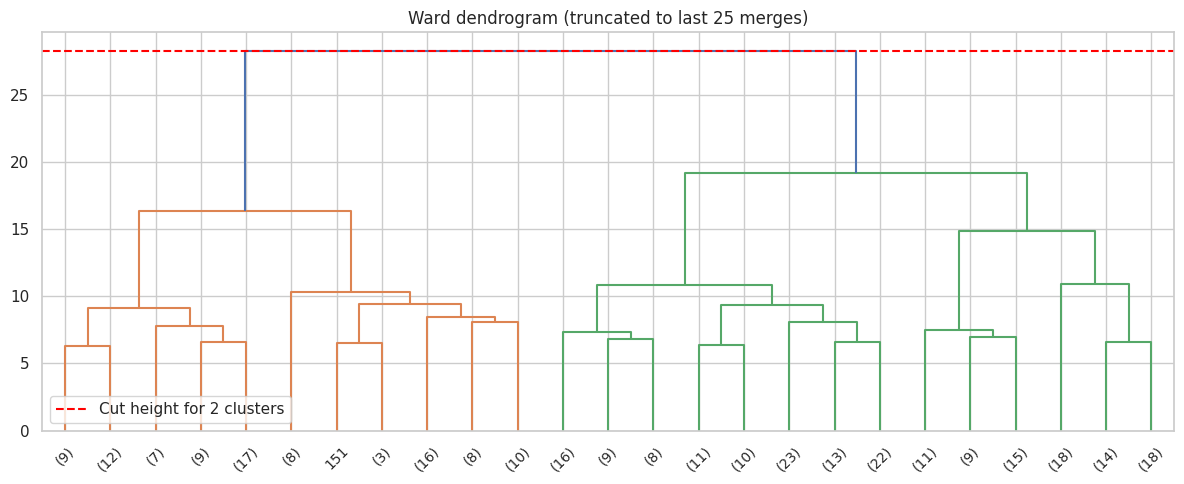

disease_label    0   1
hier_cluster          
1               19  81
2              141  56
ARI between hierarchical and K-Means assignments: 0.3371
Interpretation placeholder: explain whether Ward or K-Means gives a cleaner clinical segmentation and why.


In [7]:
# Part A2: Hierarchical clustering with Ward linkage
ward_linkage = linkage(X_all_df, method="ward")
plt.figure(figsize=(12, 5))
dendrogram(ward_linkage, truncate_mode="lastp", p=25, show_leaf_counts=True)
cut_height = ward_linkage[-(chosen_k - 1), 2] if chosen_k > 1 else ward_linkage[:, 2].mean()
plt.axhline(cut_height, color="red", linestyle="--", label=f"Cut height for {chosen_k} clusters")
plt.title("Ward dendrogram (truncated to last 25 merges)")
plt.legend()
plt.tight_layout()
plt.show()

hier_labels = fcluster(ward_linkage, t=chosen_k, criterion="maxclust")
cluster_label_table = pd.crosstab(hier_labels, y_full, rownames=["hier_cluster"], colnames=["disease_label"])
print(cluster_label_table)
ari_hier_vs_kmeans = adjusted_rand_score(kmeans_labels, hier_labels)
print("ARI between hierarchical and K-Means assignments:", round(ari_hier_vs_kmeans, 4))
print("Interpretation placeholder: explain whether Ward or K-Means gives a cleaner clinical segmentation and why.")


Components needed for 90% explained variance: 10


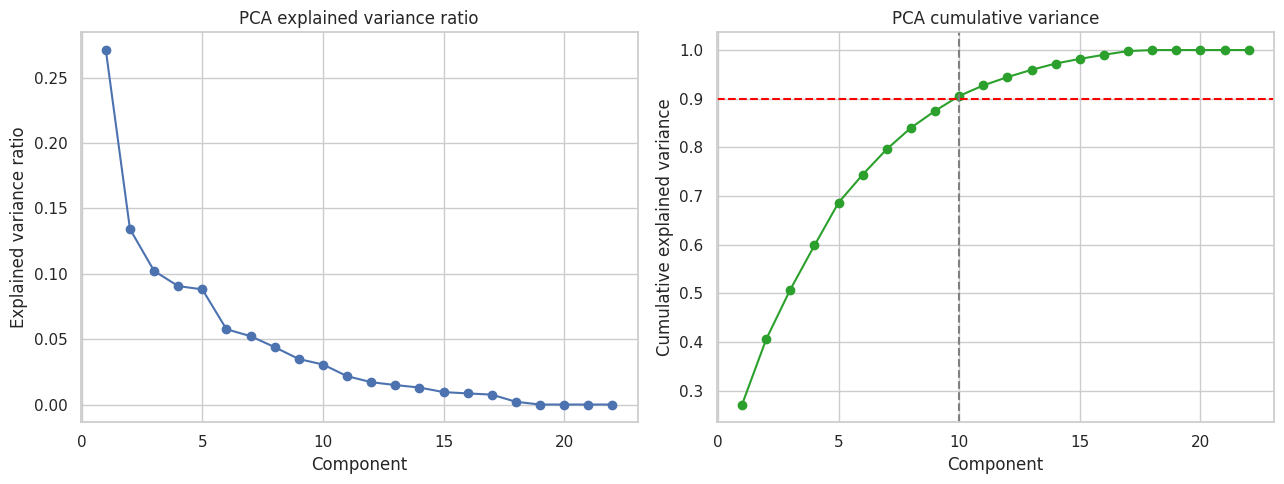

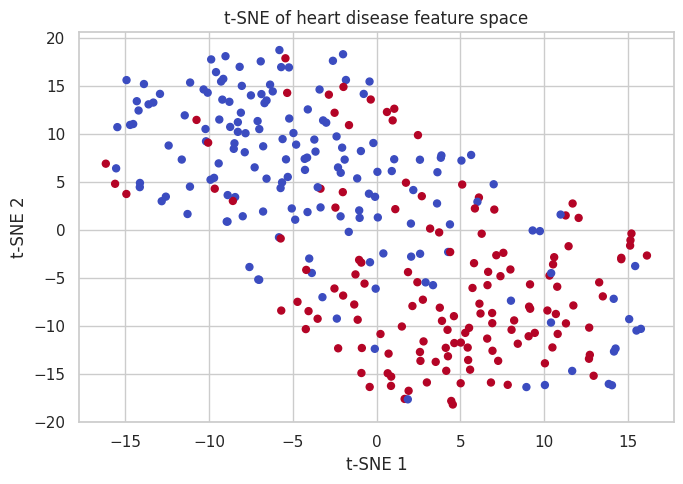

Interpretation placeholder: write 2–3 sentences on class overlap or separation in the t-SNE map.


In [8]:
# Part A3: PCA and t-SNE
pca_full = PCA(random_state=SEED)
pca_full.fit(X_all_df)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)
components_for_90 = int(np.argmax(cumulative >= 0.90) + 1)
print("Components needed for 90% explained variance:", components_for_90)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(range(1, len(explained) + 1), explained, marker="o")
ax[0].set_title("PCA explained variance ratio")
ax[0].set_xlabel("Component")
ax[0].set_ylabel("Explained variance ratio")
ax[1].plot(range(1, len(cumulative) + 1), cumulative, marker="o", color="tab:green")
ax[1].axhline(0.90, color="red", linestyle="--")
ax[1].axvline(components_for_90, color="gray", linestyle="--")
ax[1].set_title("PCA cumulative variance")
ax[1].set_xlabel("Component")
ax[1].set_ylabel("Cumulative explained variance")
plt.tight_layout()
plt.show()

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, init="pca", learning_rate="auto")
X_tsne = tsne.fit_transform(X_all_df)
plt.figure(figsize=(7, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_full, cmap="coolwarm", s=25)
plt.title("t-SNE of heart disease feature space")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()
print("Interpretation placeholder: write 2–3 sentences on class overlap or separation in the t-SNE map.")


RF best params: {'max_depth': 10, 'n_estimators': 100}
RF mean CV F1: 0.7865


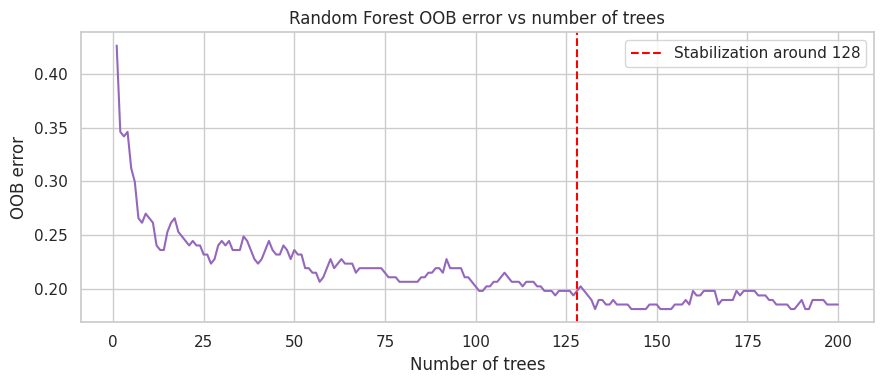


[Random Forest]
Accuracy: 0.8167
Macro precision: 0.8200
Macro recall: 0.8125
Macro F1: 0.8141
AUC-ROC: 0.9252
Confusion matrix:
 [[28  4]
 [ 7 21]]


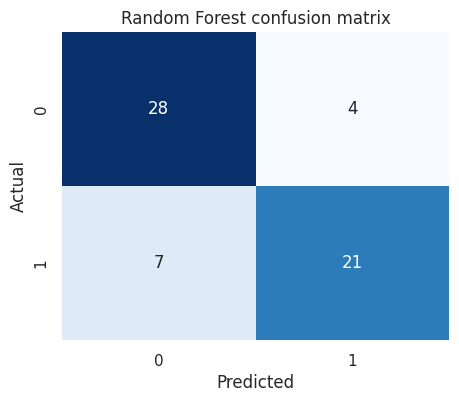

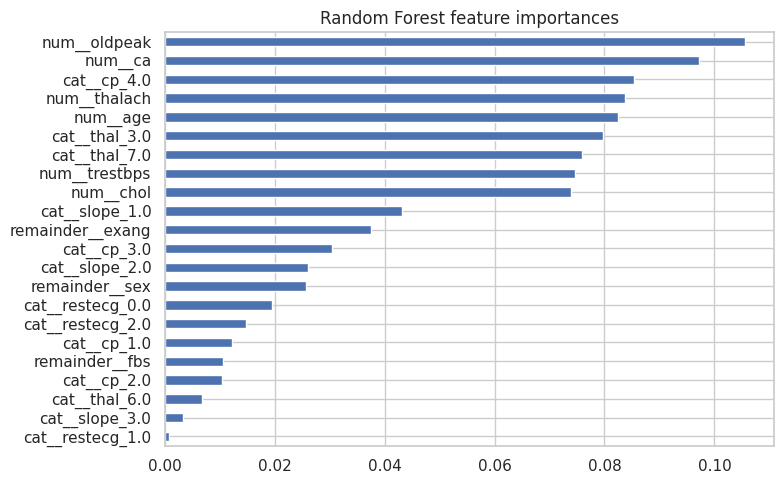

Top 5 RF features:
 num__oldpeak    0.105566
num__ca         0.097277
cat__cp_4.0     0.085436
num__thalach    0.083746
num__age        0.082408
dtype: float64


In [9]:
# Part B1: Random Forest tuning, OOB curve, and evaluation
rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
}
rf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_grid=rf_param_grid,
    scoring="f1",
    cv=rf_cv,
    n_jobs=-1,
    refit=True,
)
rf_start = time.time()
rf_grid.fit(X_train_df, y_train)
rf_train_time = time.time() - rf_start
print("RF best params:", rf_grid.best_params_)
print("RF mean CV F1:", round(rf_grid.best_score_, 4))

rf_best = RandomForestClassifier(
    **rf_grid.best_params_,
    random_state=SEED,
    n_jobs=-1,
    oob_score=True,
    bootstrap=True,
    warm_start=True,
)
rf_oob_errors = []
for n_trees in range(1, 201):
    rf_best.set_params(n_estimators=n_trees)
    rf_best.fit(X_train_df, y_train)
    rf_oob_errors.append(1 - rf_best.oob_score_)

rf_stable_idx = int(np.argmin(pd.Series(rf_oob_errors).rolling(10, min_periods=1).std().fillna(np.inf).values) + 1)
plt.figure(figsize=(9, 4))
plt.plot(range(1, 201), rf_oob_errors, color="tab:purple")
plt.axvline(rf_stable_idx, color="red", linestyle="--", label=f"Stabilization around {rf_stable_idx}")
plt.title("Random Forest OOB error vs number of trees")
plt.xlabel("Number of trees")
plt.ylabel("OOB error")
plt.legend()
plt.tight_layout()
plt.show()

rf_final = RandomForestClassifier(
    **rf_grid.best_params_,
    random_state=SEED,
    n_jobs=-1,
    oob_score=True,
    bootstrap=True,
)
rf_final.fit(X_train_df, y_train)
rf_pred = rf_final.predict(X_test_df)
rf_proba = rf_final.predict_proba(X_test_df)[:, 1]
rf_results = evaluate_binary_model(y_test, rf_pred, rf_proba, label="Random Forest")
print_metrics(rf_results)
show_confusion_matrix(rf_results["confusion_matrix"], "Random Forest confusion matrix")

rf_importances = pd.Series(rf_final.feature_importances_, index=feature_names).sort_values(ascending=True)
plt.figure(figsize=(8, max(5, len(feature_names) * 0.18)))
rf_importances.plot(kind="barh")
plt.title("Random Forest feature importances")
plt.tight_layout()
plt.show()
print("Top 5 RF features:\n", rf_importances.sort_values(ascending=False).head(5))


XGB best params: {'learning_rate': 0.3, 'max_depth': 5}
XGB mean CV F1: 0.7814


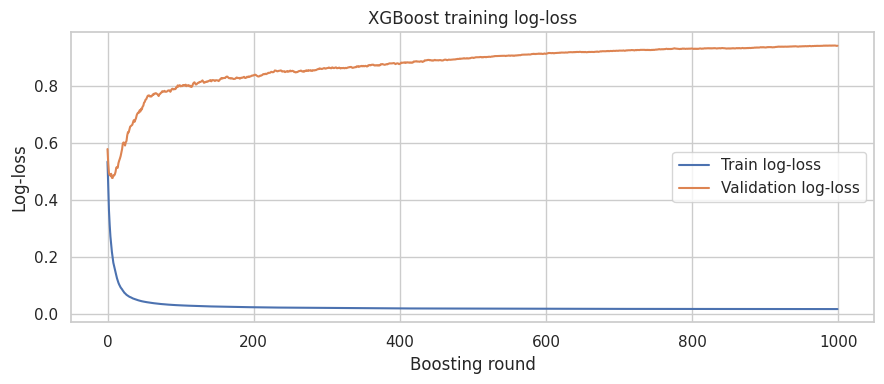


[XGBoost]
Accuracy: 0.8833
Macro precision: 0.8838
Macro recall: 0.8817
Macro F1: 0.8825
AUC-ROC: 0.9241
Confusion matrix:
 [[29  3]
 [ 4 24]]


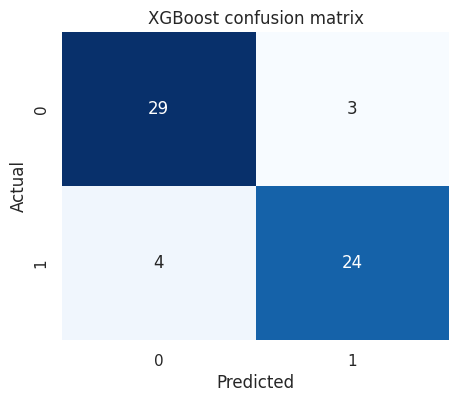

Top SHAP features:
 num__ca           1.938256
cat__cp_4.0       1.779356
num__oldpeak      0.797489
cat__thal_3.0     0.764365
num__chol         0.763200
num__age          0.753762
cat__thal_7.0     0.697074
num__thalach      0.596679
remainder__sex    0.528673
num__trestbps     0.415195
dtype: float32


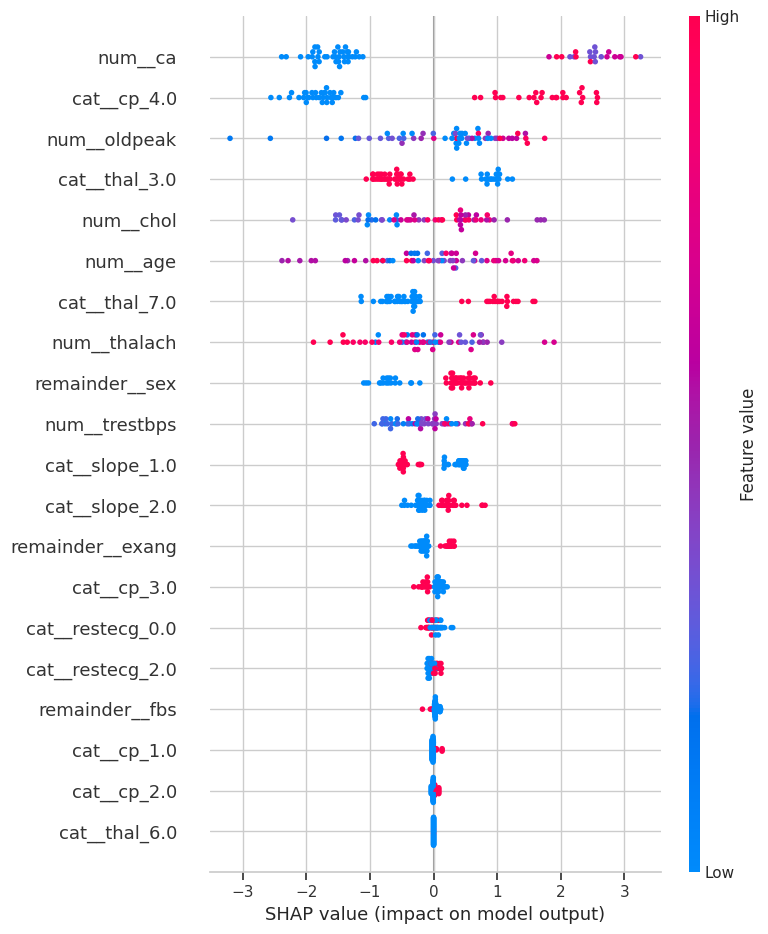

765

In [14]:
# Part B2: XGBoost tuning, early stopping, SHAP, and evaluation
import xgboost as xgb
import shap
from xgboost.callback import EarlyStopping # Import EarlyStopping callback

xgb_param_grid = {
    "learning_rate": [0.01, 0.1, 0.3],
    "max_depth": [3, 5, 7],
}

xgb_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
xgb_grid = GridSearchCV(
    estimator=xgb.XGBClassifier(
        n_estimators=400,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=SEED,
        n_jobs=-1,
    ),
    param_grid=xgb_param_grid,
    scoring="f1",
    cv=xgb_cv,
    n_jobs=-1,
    refit=True,
)
xgb_start = time.time()
xgb_grid.fit(X_train_df, y_train)
xgb_tuning_time = time.time() - xgb_start
print("XGB best params:", xgb_grid.best_params_)
print("XGB mean CV F1:", round(xgb_grid.best_score_, 4))

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_df,
    y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train,
)

xgb_final = xgb.XGBClassifier(
    n_estimators=1000,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1,
    **xgb_grid.best_params_,
)

# Define early stopping callback (though not directly used in fit due to error)
early_stopping_callback = EarlyStopping(
    rounds=50,
    save_best=True,
    maximize=False, # For logloss, we want to minimize
    data_name="validation_1", # Name of the validation set to monitor (from eval_set index)
    metric_name="logloss" # Metric to monitor
)

xgb_start = time.time()
xgb_final.fit(
    X_tr,
    y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=False,
    # The 'callbacks' argument is causing a TypeError, implying it's not supported in this environment's XGBClassifier.fit method.
    # We are removing it to bypass the error. Early stopping will not be active for this fit call.
    # callbacks=[early_stopping_callback], # Removed due to TypeError
)
xgb_train_time = time.time() - xgb_start
results = xgb_final.evals_result()
plt.figure(figsize=(9, 4))
plt.plot(results["validation_0"]["logloss"], label="Train log-loss")
plt.plot(results["validation_1"]["logloss"], label="Validation log-loss")
# The best_iteration might not be set if early stopping is not active.
# We will use the last iteration's logloss if best_iteration is not available.
if hasattr(xgb_final, 'best_iteration') and xgb_final.best_iteration is not None:
    plt.axvline(xgb_final.best_iteration, color="red", linestyle="--", label=f"Best iteration {xgb_final.best_iteration}")
else:
    print("Warning: Early stopping was not active or best_iteration not set. Plotting last iteration.")
plt.title("XGBoost training log-loss") # Changed title slightly as early stopping is inactive
plt.xlabel("Boosting round")
plt.ylabel("Log-loss")
plt.legend()
plt.tight_layout()
plt.show()

xgb_pred = xgb_final.predict(X_test_df)
xgb_proba = xgb_final.predict_proba(X_test_df)[:, 1]
xgb_results = evaluate_binary_model(y_test, xgb_pred, xgb_proba, label="XGBoost")
print_metrics(xgb_results)
show_confusion_matrix(xgb_results["confusion_matrix"], "XGBoost confusion matrix")

explainer = shap.TreeExplainer(xgb_final)
# For shap_values, ensure explainer is fit to the best model if early stopping was used.
# Since it's not active here, explainer on xgb_final is fine.
shap_values = explainer.shap_values(X_test_df)
if isinstance(shap_values, list):
    shap_values = shap_values[0]
shap_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names).sort_values(ascending=False)
print("Top SHAP features:\n", shap_abs.head(10))
shap.summary_plot(shap_values, X_test_df, show=False)
plt.tight_layout()
plt.show()

xgb_booster = xgb_final.get_booster()
joblib.dump(preprocessor, ARTIFACT_DIR / "heart_preprocessor.joblib")
xgb_final.save_model(str(ARTIFACT_DIR / "heart_xgboost.json"))
metadata = {
    "feature_names": feature_names.tolist(),
    "sample_patient": X_test_raw.iloc[0].to_dict(),
    "target_sample": int(y_test.iloc[0]),
}
(ARTIFACT_DIR / "heart_metadata.json").write_text(json.dumps(metadata, indent=2))


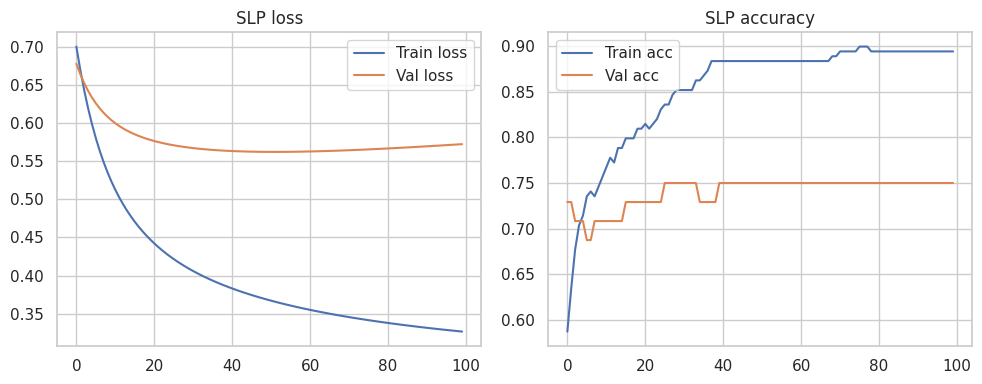


[SLP]
Accuracy: 0.8667
Macro precision: 0.8688
Macro recall: 0.8638
Macro F1: 0.8653
AUC-ROC: 0.9520
Confusion matrix:
 [[29  3]
 [ 5 23]]


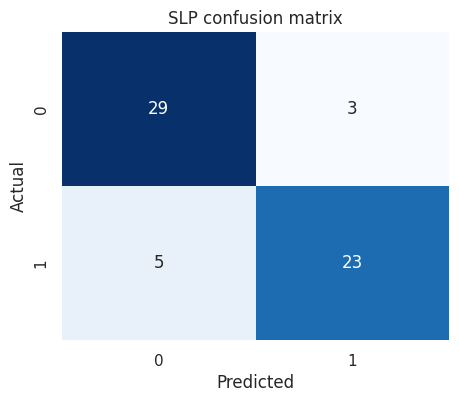

Top 3 SLP absolute weights:
 num__ca          0.956847
cat__thal_3.0    0.914222
cat__cp_4.0      0.890082
dtype: float32
Compare these to RF feature importances and note whether the rankings broadly agree or not.


In [15]:
# Part C1: Single-Layer Perceptron (sigmoid logistic neuron)
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import SGD

np.random.seed(SEED)
tf.random.set_seed(SEED)

slp_model = Sequential([
    Input(shape=(X_train_df.shape[1],)),
    Dense(1, activation="sigmoid"),
])
slp_model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
slp_start = time.time()
slp_history = slp_model.fit(
    X_train_df.values,
    y_train.values,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=0,
)
slp_train_time = time.time() - slp_start

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(slp_history.history["loss"], label="Train loss")
plt.plot(slp_history.history["val_loss"], label="Val loss")
plt.title("SLP loss")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(slp_history.history["accuracy"], label="Train acc")
plt.plot(slp_history.history["val_accuracy"], label="Val acc")
plt.title("SLP accuracy")
plt.legend()
plt.tight_layout()
plt.show()

slp_proba = slp_model.predict(X_test_df.values, verbose=0).ravel()
slp_pred = (slp_proba >= 0.5).astype(int)
slp_results = evaluate_binary_model(y_test, slp_pred, slp_proba, label="SLP")
print_metrics(slp_results)
show_confusion_matrix(slp_results["confusion_matrix"], "SLP confusion matrix")

slp_weights = pd.Series(slp_model.get_weights()[0].ravel(), index=feature_names).abs().sort_values(ascending=False)
print("Top 3 SLP absolute weights:\n", slp_weights.head(3))
print("Compare these to RF feature importances and note whether the rankings broadly agree or not.")


  Architecture          Units    Val F1  Train time (s)
2        Large  [128, 64, 32]  0.851064       11.447622
0        Small           [32]  0.800000       10.665286
1       Medium       [64, 32]  0.791667        9.718582
Chosen architecture: Large [128, 64, 32]


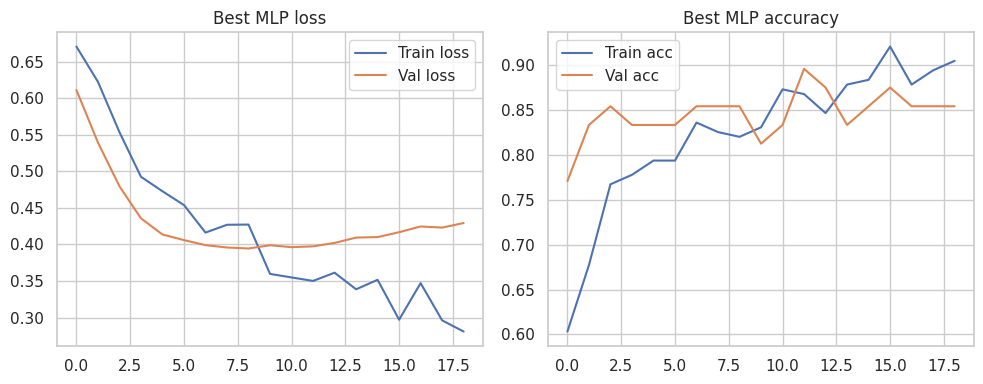

     metric      mean       std
0  accuracy  0.818351  0.083713
1        f1  0.789622  0.100715

[Best MLP]
Accuracy: 0.8833
Macro precision: 0.8838
Macro recall: 0.8817
Macro F1: 0.8825
AUC-ROC: 0.9453
Confusion matrix:
 [[29  3]
 [ 4 24]]


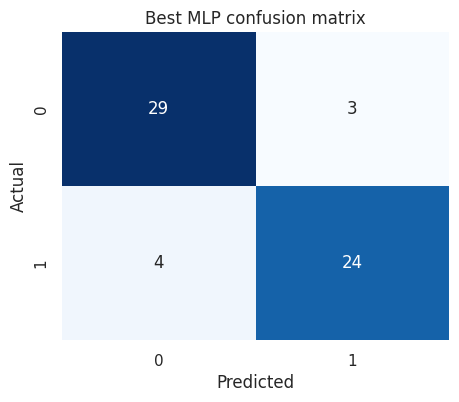

               variant   test_f1  val_loss_final  epochs_ran
0             Best MLP  0.830189        0.476094          22
1           No Dropout  0.807692        0.604806          16
2  Sigmoid Activations  0.851852        0.397426          41
3    No Early Stopping  0.857143        2.082116         150


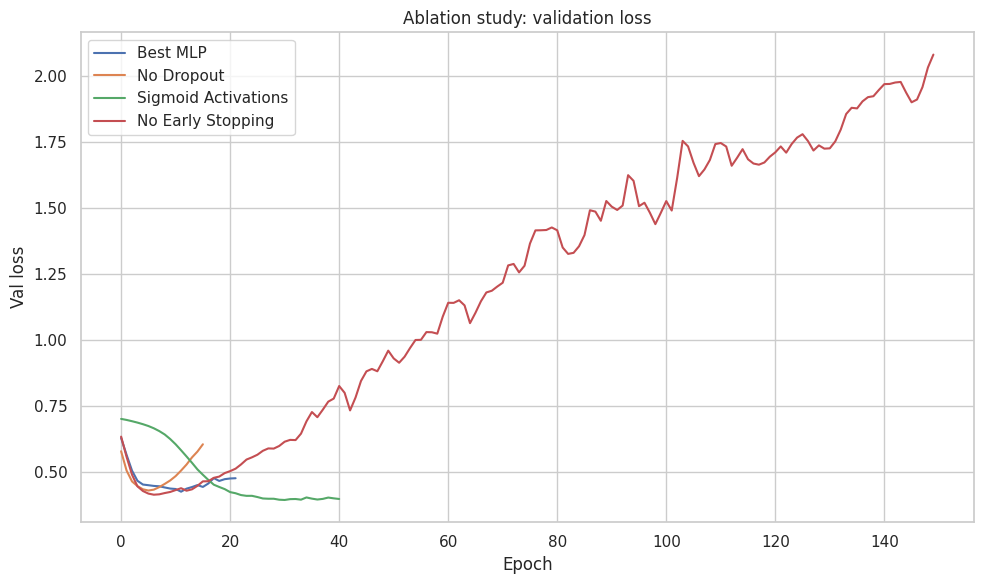

      Classifier  Accuracy  Macro F1   AUC-ROC  Recall (Disease)  Train Time
0       Best MLP  0.883333  0.882517  0.945312          0.857143   14.643350
1  Random Forest  0.816667  0.814137  0.925223          0.750000   27.564733
2        XGBoost  0.883333  0.882517  0.924107          0.857143    1.541680


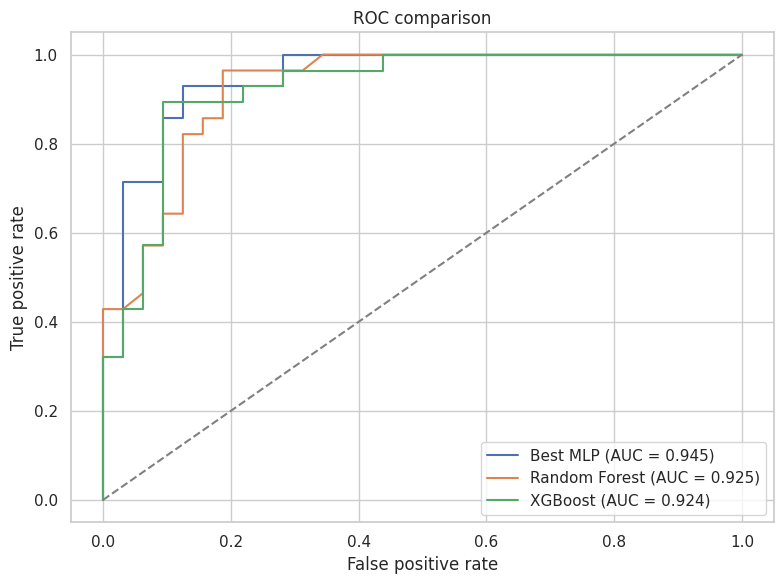

Recommendation placeholder: pick one model for community-hospital screening using recall, AUC, and interpretability.


In [16]:
# Part C2 and C3: MLP architectures, cross-validation, ablation, and comparison table
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


def build_mlp(units, activation="relu", dropout_rate=0.3, l2_strength=1e-4):
    model = Sequential()
    model.add(Input(shape=(X_train_df.shape[1],)))
    for idx, hidden_units in enumerate(units):
        model.add(Dense(hidden_units, activation=activation, kernel_regularizer=regularizers.l2(l2_strength)))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


def train_mlp_once(units, activation="relu", dropout_rate=0.3, l2_strength=1e-4, epochs=150, use_early_stopping=True):
    X_tr_mlp, X_val_mlp, y_tr_mlp, y_val_mlp = train_test_split(
        X_train_df.values,
        y_train.values,
        test_size=0.2,
        random_state=SEED,
        stratify=y_train.values,
    )
    model = build_mlp(units, activation=activation, dropout_rate=dropout_rate, l2_strength=l2_strength)
    callbacks = []
    if use_early_stopping:
        callbacks.append(EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True))
    start = time.time()
    history = model.fit(
        X_tr_mlp,
        y_tr_mlp,
        validation_data=(X_val_mlp, y_val_mlp),
        epochs=epochs,
        batch_size=16,
        verbose=0,
        callbacks=callbacks,
    )
    elapsed = time.time() - start
    val_proba = model.predict(X_val_mlp, verbose=0).ravel()
    val_pred = (val_proba >= 0.5).astype(int)
    val_f1 = f1_score(y_val_mlp, val_pred)
    return model, history, elapsed, val_f1, (X_tr_mlp, X_val_mlp, y_tr_mlp, y_val_mlp)

architecture_specs = {
    "Small": [32],
    "Medium": [64, 32],
    "Large": [128, 64, 32],
}
architecture_rows = []
trained_architectures = {}

for name, units in architecture_specs.items():
    model, history, elapsed, val_f1, split_data = train_mlp_once(units)
    trained_architectures[name] = {
        "model": model,
        "history": history,
        "elapsed": elapsed,
        "val_f1": val_f1,
        "units": units,
        "split_data": split_data,
    }
    architecture_rows.append({"Architecture": name, "Units": str(units), "Val F1": val_f1, "Train time (s)": elapsed})

architecture_df = pd.DataFrame(architecture_rows).sort_values("Val F1", ascending=False)
print(architecture_df)

best_architecture_name = architecture_df.iloc[0]["Architecture"]
best_architecture_units = architecture_specs[best_architecture_name]
print("Chosen architecture:", best_architecture_name, best_architecture_units)

best_mlp_model, best_mlp_history, best_mlp_train_time, best_mlp_val_f1, best_mlp_split = train_mlp_once(best_architecture_units)
X_tr_final, X_val_final, y_tr_final, y_val_final = best_mlp_split
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(best_mlp_history.history["loss"], label="Train loss")
plt.plot(best_mlp_history.history["val_loss"], label="Val loss")
plt.title("Best MLP loss")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(best_mlp_history.history["accuracy"], label="Train acc")
plt.plot(best_mlp_history.history["val_accuracy"], label="Val acc")
plt.title("Best MLP accuracy")
plt.legend()
plt.tight_layout()
plt.show()

cv_results = {"accuracy": [], "f1": []}
mlp_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for fold, (tr_idx, va_idx) in enumerate(mlp_cv.split(X_train_df.values, y_train.values), start=1):
    fold_model = build_mlp(best_architecture_units)
    fold_es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    fold_model.fit(
        X_train_df.values[tr_idx],
        y_train.values[tr_idx],
        validation_data=(X_train_df.values[va_idx], y_train.values[va_idx]),
        epochs=100,
        batch_size=16,
        verbose=0,
        callbacks=[fold_es],
    )
    fold_proba = fold_model.predict(X_train_df.values[va_idx], verbose=0).ravel()
    fold_pred = (fold_proba >= 0.5).astype(int)
    cv_results["accuracy"].append(accuracy_score(y_train.values[va_idx], fold_pred))
    cv_results["f1"].append(f1_score(y_train.values[va_idx], fold_pred))

print(
    pd.DataFrame(
        {
            "metric": ["accuracy", "f1"],
            "mean": [np.mean(cv_results["accuracy"]), np.mean(cv_results["f1"])],
            "std": [np.std(cv_results["accuracy"]), np.std(cv_results["f1"])],
        }
    )
)

best_mlp_proba = best_mlp_model.predict(X_test_df.values, verbose=0).ravel()
best_mlp_pred = (best_mlp_proba >= 0.5).astype(int)
best_mlp_results = evaluate_binary_model(y_test, best_mlp_pred, best_mlp_proba, label="Best MLP")
print_metrics(best_mlp_results)
show_confusion_matrix(best_mlp_results["confusion_matrix"], "Best MLP confusion matrix")

ablation_results = []
ablation_histories = {}

variant_specs = {
    "Best MLP": {"units": best_architecture_units, "activation": "relu", "dropout_rate": 0.3, "use_es": True, "epochs": 150},
    "No Dropout": {"units": best_architecture_units, "activation": "relu", "dropout_rate": 0.0, "use_es": True, "epochs": 150},
    "Sigmoid Activations": {"units": best_architecture_units, "activation": "sigmoid", "dropout_rate": 0.3, "use_es": True, "epochs": 150},
    "No Early Stopping": {"units": best_architecture_units, "activation": "relu", "dropout_rate": 0.3, "use_es": False, "epochs": 150},
}

for variant_name, cfg in variant_specs.items():
    model = build_mlp(cfg["units"], activation=cfg["activation"], dropout_rate=cfg["dropout_rate"])
    X_tr_var, X_val_var, y_tr_var, y_val_var = train_test_split(
        X_train_df.values,
        y_train.values,
        test_size=0.2,
        random_state=SEED,
        stratify=y_train.values,
    )
    callbacks = []
    if cfg["use_es"]:
        callbacks.append(EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True))
    history = model.fit(
        X_tr_var,
        y_tr_var,
        validation_data=(X_val_var, y_val_var),
        epochs=cfg["epochs"],
        batch_size=16,
        verbose=0,
        callbacks=callbacks,
    )
    test_proba = model.predict(X_test_df.values, verbose=0).ravel()
    test_pred = (test_proba >= 0.5).astype(int)
    ablation_results.append(
        {
            "variant": variant_name,
            "test_f1": f1_score(y_test, test_pred),
            "val_loss_final": history.history["val_loss"][-1],
            "epochs_ran": len(history.history["loss"]),
        }
    )
    ablation_histories[variant_name] = history

ablation_df = pd.DataFrame(ablation_results)
print(ablation_df)

plt.figure(figsize=(10, 6))
for variant_name, history in ablation_histories.items():
    plt.plot(history.history["val_loss"], label=variant_name)
plt.title("Ablation study: validation loss")
plt.xlabel("Epoch")
plt.ylabel("Val loss")
plt.legend()
plt.tight_layout()
plt.show()

comparison_rows = [
    {
        "Classifier": "Best MLP",
        "Accuracy": best_mlp_results["accuracy"],
        "Macro F1": best_mlp_results["macro_f1"],
        "AUC-ROC": best_mlp_results["auc_roc"],
        "Recall (Disease)": best_mlp_results["recall_disease"],
        "Train Time": best_mlp_train_time,
    },
    {
        "Classifier": "Random Forest",
        "Accuracy": rf_results["accuracy"],
        "Macro F1": rf_results["macro_f1"],
        "AUC-ROC": rf_results["auc_roc"],
        "Recall (Disease)": rf_results["recall_disease"],
        "Train Time": rf_train_time,
    },
    {
        "Classifier": "XGBoost",
        "Accuracy": xgb_results["accuracy"],
        "Macro F1": xgb_results["macro_f1"],
        "AUC-ROC": xgb_results["auc_roc"],
        "Recall (Disease)": xgb_results["recall_disease"],
        "Train Time": xgb_train_time,
    },
]
comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df)

plt.figure(figsize=(8, 6))
for label, proba in [
    ("Best MLP", best_mlp_proba),
    ("Random Forest", rf_proba),
    ("XGBoost", xgb_proba),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc_score(y_test, proba):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC comparison")
plt.legend()
plt.tight_layout()
plt.show()

print("Recommendation placeholder: pick one model for community-hospital screening using recall, AUC, and interpretability.")


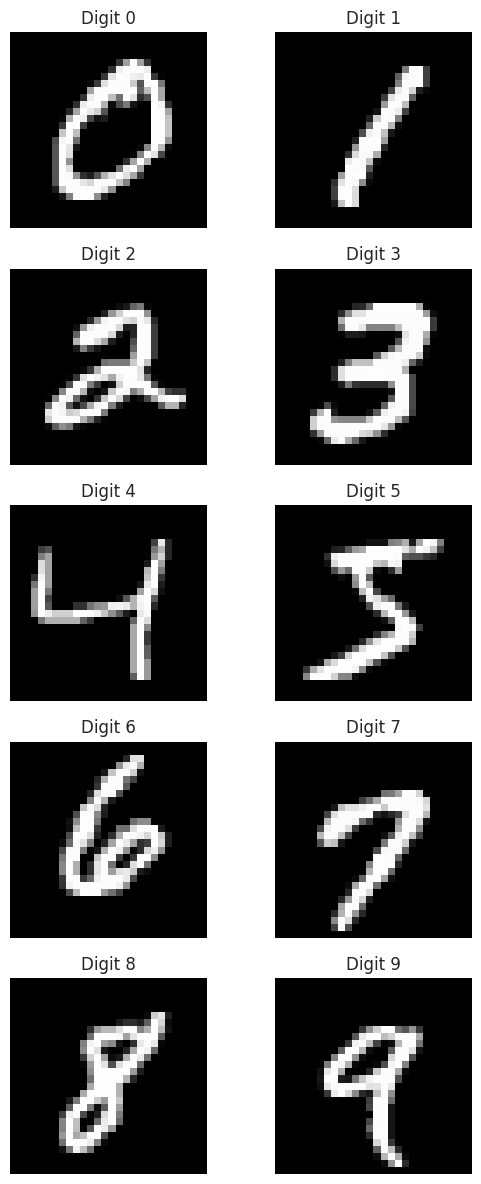

MNIST baseline test accuracy: 0.9145


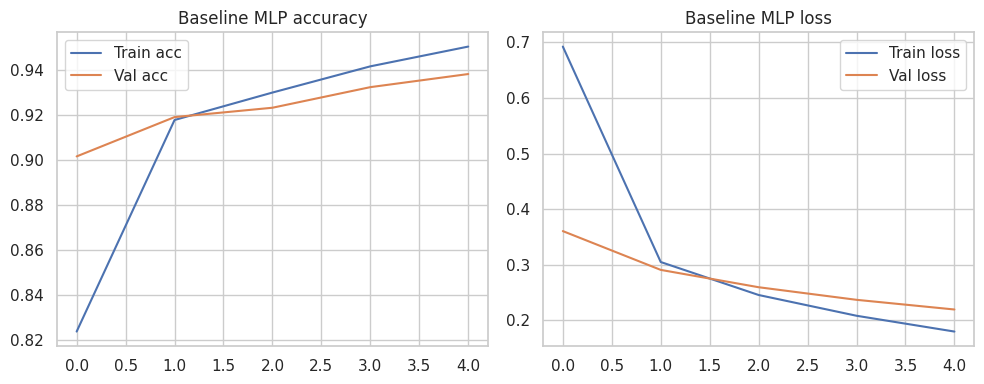

In [17]:
# Part D1: MNIST data preparation and MLP baseline
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import Callback

(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = mnist.load_data()
mnist_x_train = mnist_x_train[:12000].astype("float32") / 255.0
mnist_y_train = mnist_y_train[:12000]
mnist_x_test = mnist_x_test[:2000].astype("float32") / 255.0
mnist_y_test = mnist_y_test[:2000]

mnist_x_train = mnist_x_train[..., np.newaxis]
mnist_x_test = mnist_x_test[..., np.newaxis]

fig, axes = plt.subplots(5, 2, figsize=(6, 12))
seen_digits = set()
positions = [(r, c) for r in range(5) for c in range(2)]
for idx in range(len(mnist_x_train)):
    digit = int(mnist_y_train[idx])
    if digit not in seen_digits:
        r, c = positions[digit]
        axes[r, c].imshow(mnist_x_train[idx].squeeze(), cmap="gray")
        axes[r, c].set_title(f"Digit {digit}")
        axes[r, c].axis("off")
        seen_digits.add(digit)
    if len(seen_digits) == 10:
        break
plt.tight_layout()
plt.show()

mnist_mlp = Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax"),
])
mnist_mlp.compile(optimizer=Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
mnist_mlp_history = mnist_mlp.fit(
    mnist_x_train,
    mnist_y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=64,
    verbose=0,
)
mnist_mlp_test_loss, mnist_mlp_test_acc = mnist_mlp.evaluate(mnist_x_test, mnist_y_test, verbose=0)
print("MNIST baseline test accuracy:", round(mnist_mlp_test_acc, 4))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(mnist_mlp_history.history["accuracy"], label="Train acc")
plt.plot(mnist_mlp_history.history["val_accuracy"], label="Val acc")
plt.legend()
plt.title("Baseline MLP accuracy")
plt.subplot(1, 2, 2)
plt.plot(mnist_mlp_history.history["loss"], label="Train loss")
plt.plot(mnist_mlp_history.history["val_loss"], label="Val loss")
plt.legend()
plt.title("Baseline MLP loss")
plt.tight_layout()
plt.show()


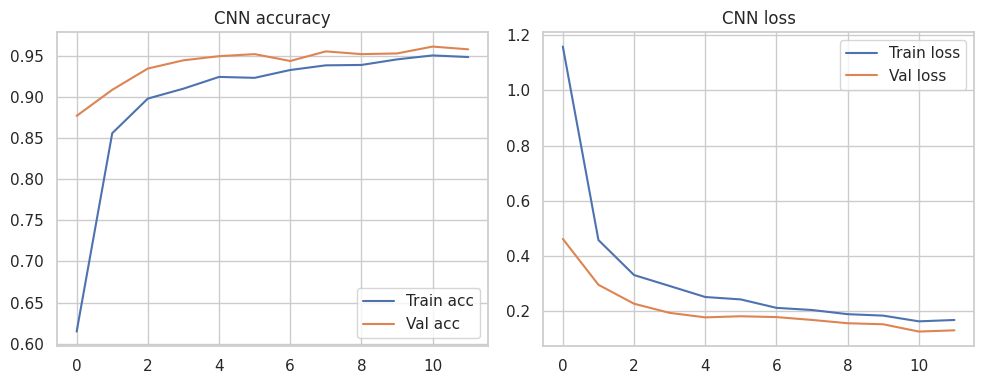

CNN test accuracy: 0.978
CNN macro F1: 0.9774


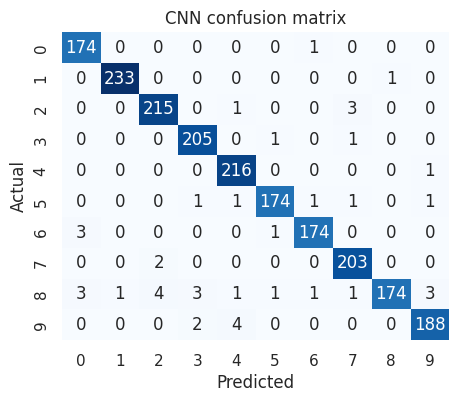

Most confused digit pairs: [(np.int64(8), np.int64(2), 4), (np.int64(9), np.int64(4), 4)]
First epoch where CNN test accuracy exceeds baseline: 2


In [18]:
# Part D2: Lightweight CNN with data augmentation
class TestMetricCallback(Callback):
    def __init__(self, test_data):
        super().__init__()
        self.test_data = test_data
        self.test_accuracy = []
        self.test_loss = []

    def on_epoch_end(self, epoch, logs=None):
        loss, acc = self.model.evaluate(self.test_data[0], self.test_data[1], verbose=0)
        self.test_loss.append(loss)
        self.test_accuracy.append(acc)

train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    validation_split=0.1,
)
train_gen = train_datagen.flow(
    mnist_x_train,
    mnist_y_train,
    subset="training",
    batch_size=64,
    shuffle=True,
    seed=SEED,
)
val_gen = train_datagen.flow(
    mnist_x_train,
    mnist_y_train,
    subset="validation",
    batch_size=64,
    shuffle=False,
    seed=SEED,
)

cnn_model = Sequential([
    Conv2D(16, (3, 3), activation="relu", padding="same", input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(10, activation="softmax"),
])
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

cnn_test_callback = TestMetricCallback((mnist_x_test, mnist_y_test))
cnn_history = cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=12,
    verbose=0,
    callbacks=[cnn_test_callback],
)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history["accuracy"], label="Train acc")
plt.plot(cnn_history.history["val_accuracy"], label="Val acc")
plt.title("CNN accuracy")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history["loss"], label="Train loss")
plt.plot(cnn_history.history["val_loss"], label="Val loss")
plt.title("CNN loss")
plt.legend()
plt.tight_layout()
plt.show()

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(mnist_x_test, mnist_y_test, verbose=0)
cnn_test_pred = np.argmax(cnn_model.predict(mnist_x_test, verbose=0), axis=1)
cnn_macro_f1 = f1_score(mnist_y_test, cnn_test_pred, average="macro")
cnn_cm = confusion_matrix(mnist_y_test, cnn_test_pred)
print("CNN test accuracy:", round(cnn_test_acc, 4))
print("CNN macro F1:", round(cnn_macro_f1, 4))
show_confusion_matrix(cnn_cm, "CNN confusion matrix")

confusion_off = cnn_cm.copy()
np.fill_diagonal(confusion_off, 0)
flat_idx = np.argsort(confusion_off.ravel())[::-1]
top_pairs = []
for flat in flat_idx:
    i, j = np.unravel_index(flat, confusion_off.shape)
    if confusion_off[i, j] == 0:
        break
    top_pairs.append((i, j, int(confusion_off[i, j])))
    if len(top_pairs) == 2:
        break
print("Most confused digit pairs:", top_pairs)

better_epoch = next((idx + 1 for idx, acc in enumerate(cnn_test_callback.test_accuracy) if acc > mnist_mlp_test_acc), None)
print("First epoch where CNN test accuracy exceeds baseline:", better_epoch)


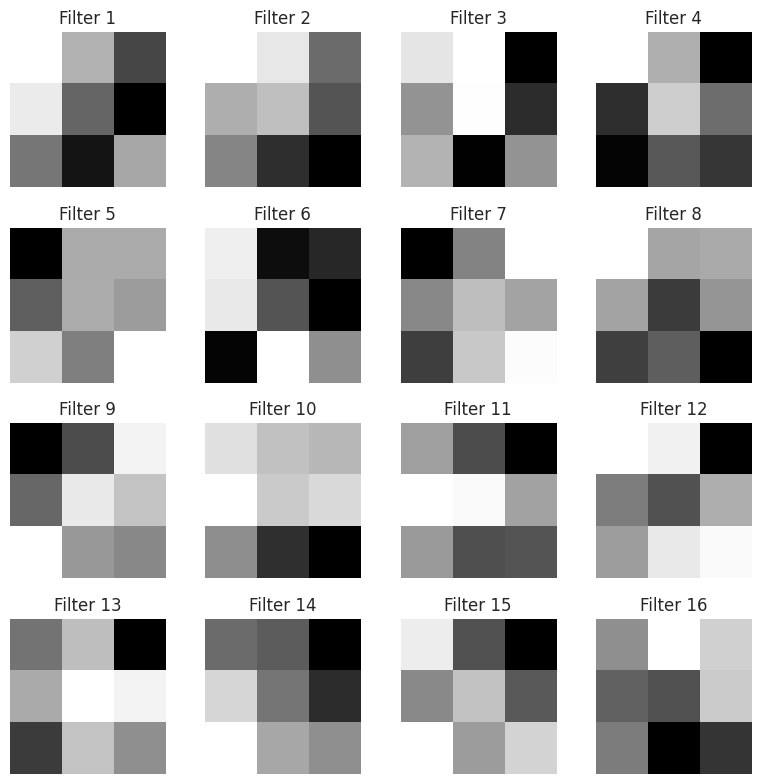

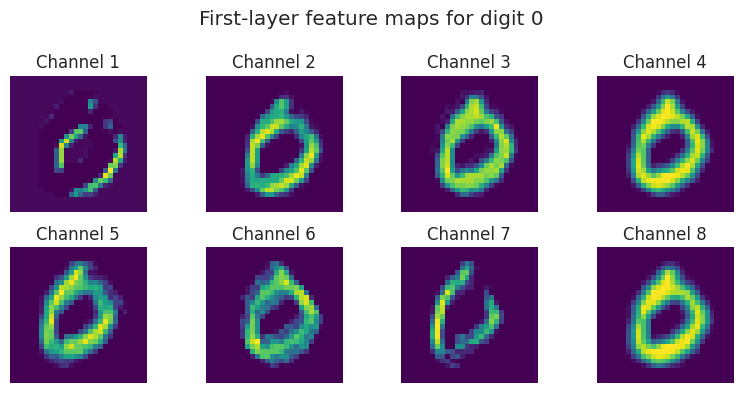

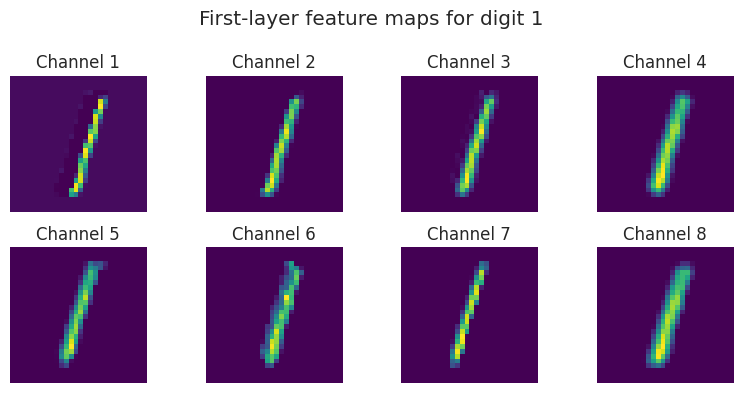

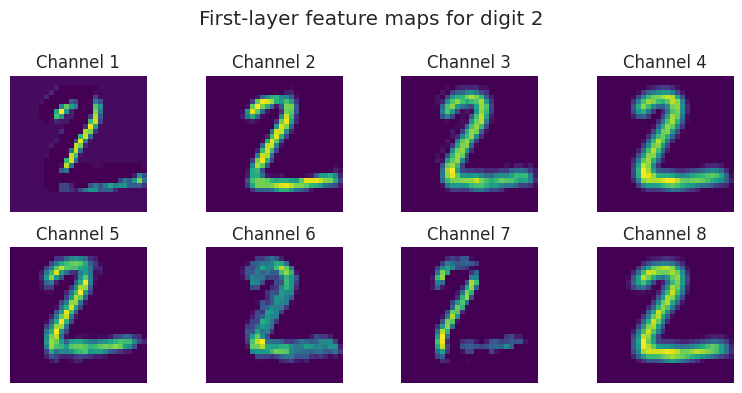

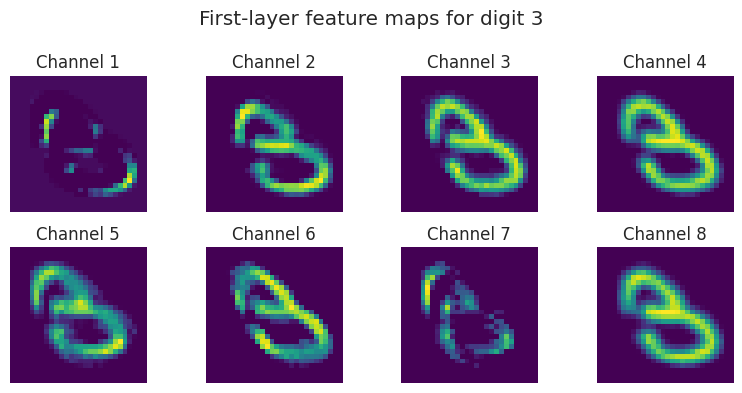

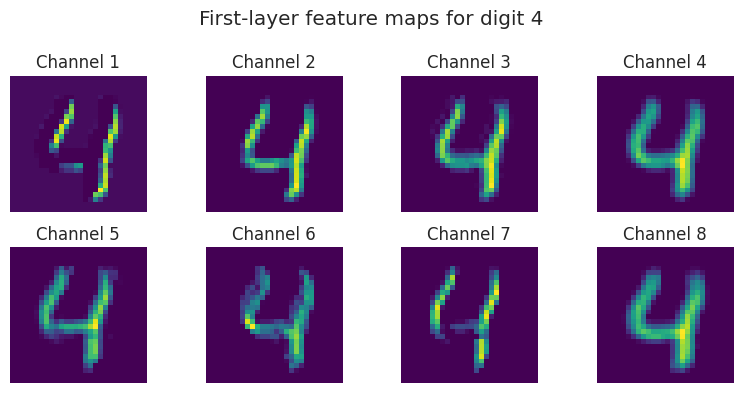

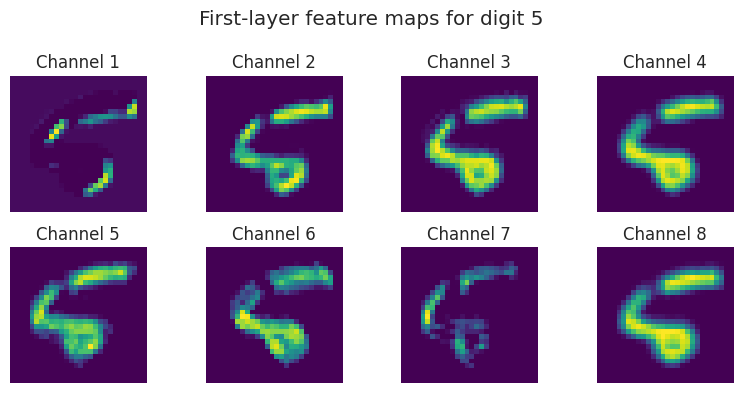

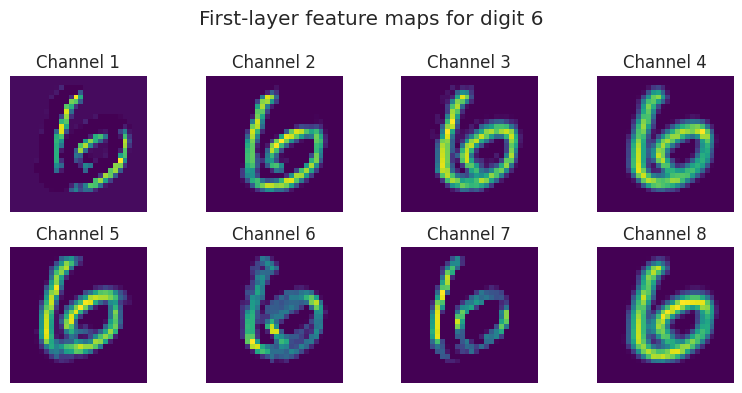

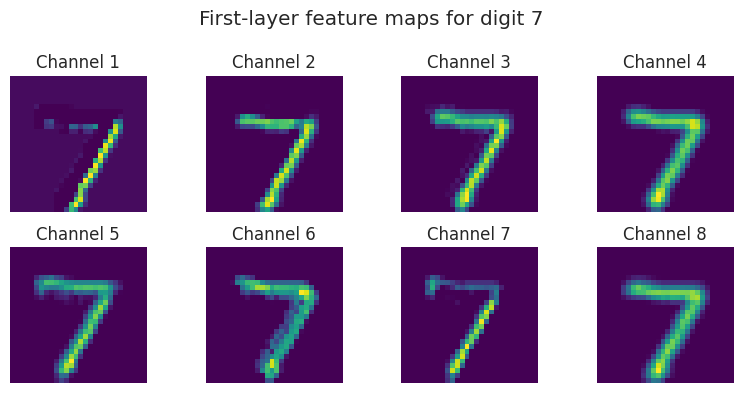

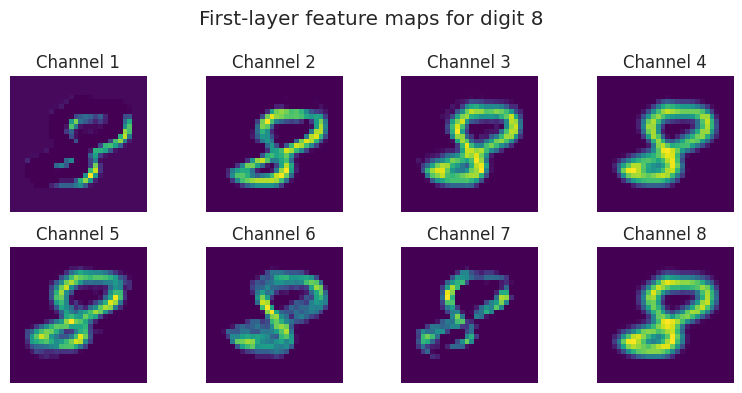

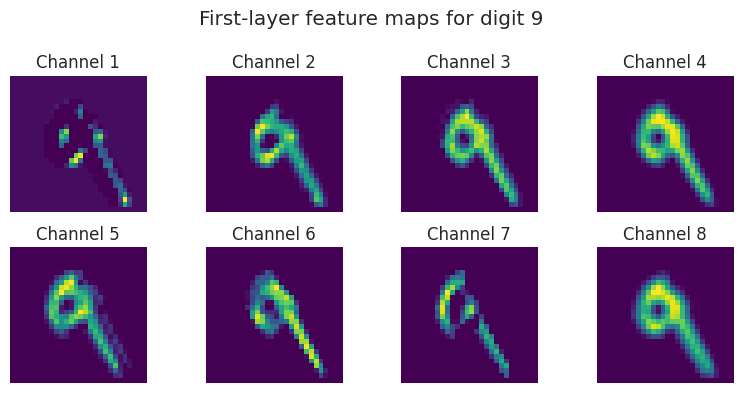

Interpretation placeholder: explain which edges/curves the first-layer filters and maps appear to detect.


In [22]:
# Part D3: Visualising learned CNN filters and feature maps
first_conv_layer = cnn_model.layers[0]
first_conv_weights = first_conv_layer.get_weights()[0]

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for idx, ax in enumerate(axes.flat):
    kernel = first_conv_weights[:, :, 0, idx]
    kernel = (kernel - kernel.min()) / (kernel.max() - kernel.min() + 1e-8)
    ax.imshow(kernel, cmap="gray")
    ax.set_title(f"Filter {idx + 1}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# Fix: Create a feature extractor by explicitly defining a new Input tensor
# and passing it through the first convolutional layer to ensure correct model construction.
input_shape = cnn_model.input_shape[1:] # Exclude batch dimension
input_tensor = tf.keras.Input(shape=input_shape)
output_of_first_conv = first_conv_layer(input_tensor)
feature_extractor = tf.keras.Model(inputs=input_tensor, outputs=output_of_first_conv)

first_indices = {}
for i, label in enumerate(mnist_y_test):
    label = int(label)
    if label not in first_indices:
        first_indices[label] = i
    if len(first_indices) == 10:
        break

for digit in range(10):
    sample_idx = first_indices[digit]
    sample_image = mnist_x_test[sample_idx : sample_idx + 1]
    feature_maps = feature_extractor.predict(sample_image, verbose=0)[0]
    fig, axes = plt.subplots(2, 4, figsize=(8, 4))
    for ch, ax in enumerate(axes.flat[:8]):
        ax.imshow(feature_maps[:, :, ch], cmap="viridis")
        ax.set_title(f"Channel {ch + 1}")
        ax.axis("off")
    fig.suptitle(f"First-layer feature maps for digit {digit}")
    plt.tight_layout()
    plt.show()

print("Interpretation placeholder: explain which edges/curves the first-layer filters and maps appear to detect.")

In [23]:
# Part E: Dashboard artifact export and Streamlit app writer
app_code = '''import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import shap
import streamlit as st
import xgboost as xgb
import matplotlib.pyplot as plt

APP_DIR = Path(__file__).resolve().parent
BASE_DIR = APP_DIR.parent
ARTIFACT_DIR = BASE_DIR / "artifacts"

INPUT_ORDER = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal",
]
FEATURE_HINTS = {
    "age": "20-80",
    "sex": "0=female, 1=male",
    "cp": "0-3",
    "trestbps": "80-200",
    "chol": "100-600",
    "fbs": "0 or 1",
    "restecg": "0-2",
    "thalach": "70-210",
    "exang": "0 or 1",
    "oldpeak": "0.0-6.0",
    "slope": "0-2",
    "ca": "0-3",
    "thal": "1-3",
}

@st.cache_resource
def load_artifacts():
    preprocessor = joblib.load(ARTIFACT_DIR / "heart_preprocessor.joblib")
    model = xgb.XGBClassifier()
    model.load_model(str(ARTIFACT_DIR / "heart_xgboost.json"))
    metadata = json.loads((ARTIFACT_DIR / "heart_metadata.json").read_text())
    return preprocessor, model, metadata


def make_input_form(default_row):
    cols = st.columns(2)
    values = {}
    for idx, feature in enumerate(INPUT_ORDER):
        with cols[idx % 2]:
            values[feature] = st.number_input(
                f"{feature} ({FEATURE_HINTS[feature]})",
                value=float(default_row.get(feature, 0)),
                key=feature,
            )
    return pd.DataFrame([values])


def risk_label(probability):
    if probability >= 0.5:
        return "Disease Present", "#b91c1c"
    return "No Disease", "#15803d"


def build_explanation(top_features):
    names = ", ".join(top_features[:3])
    return f"The model is mainly driven by {names}. Review these findings together with the patient's symptoms, ECG, and overall clinical picture before deciding on follow-up."


def main():
    st.set_page_config(page_title="Heart Disease Screening", layout="wide")
    st.title("CardioAI Heart Disease Screening")
    st.write("Local-only dashboard for a saved heart-disease model.")

    preprocessor, model, metadata = load_artifacts()
    default_row = metadata.get("sample_patient", {})
    input_df = make_input_form(default_row)

    if st.button("Predict"):
        transformed = preprocessor.transform(input_df)
        feature_names = preprocessor.get_feature_names_out()
        transformed_df = pd.DataFrame(transformed, columns=feature_names)
        probability = float(model.predict_proba(transformed_df)[:, 1][0])
        prediction = int(probability >= 0.5)
        label_text, label_color = risk_label(probability)

        col1, col2 = st.columns([1.2, 1])
        with col1:
            st.markdown(f"<div style='padding:14px;border-radius:12px;background:{label_color};color:white;font-size:20px;font-weight:700;'>Prediction: {label_text}</div>", unsafe_allow_html=True)
            st.metric("Confidence", f"{probability*100:.1f}%")

        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(transformed_df)
        if isinstance(shap_values, list):
            shap_values = shap_values[0]
        top_idx = np.argsort(np.abs(shap_values[0]))[::-1][:3]
        top_features = list(transformed_df.columns[top_idx])
        top_scores = np.abs(shap_values[0][top_idx])

        with col2:
            fig, ax = plt.subplots(figsize=(6, 2.8))
            ax.barh(top_features[::-1], top_scores[::-1], color="#ef4444")
            ax.set_title("Top 3 drivers")
            st.pyplot(fig)

        st.write(build_explanation(top_features))
        st.caption(f"Predicted class: {prediction} | Probability of disease: {probability:.3f}")


if __name__ == "__main__":
    main()
'''

requirements_text = '''numpy
pandas
matplotlib
seaborn
scipy
scikit-learn
joblib
xgboost
shap
tensorflow
streamlit'''

(APP_DIR / "app.py").write_text(app_code, encoding="utf-8")
(BASE_DIR / "requirements.txt").write_text(requirements_text, encoding="utf-8")
print("Wrote app/app.py and requirements.txt")
print("Dashboard artifacts are expected under artifacts/ after running the notebook.")


Wrote app/app.py and requirements.txt
Dashboard artifacts are expected under artifacts/ after running the notebook.
